In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/stsb_multi_mt_nepali_cleaned.csv


In [2]:
#pip install transformers datasets torch pandas sentence-transformers


In [3]:
df = pd.read_csv('/kaggle/input/stsb_multi_mt_nepali_cleaned.csv')
df.head()

,sentence1,sentence2,score
0,एउटा विमान उडिरहेको छ।,हवाई जहाज उडिरहेको छ।,5.00
1,एउटा मान्छे ठूलो बाँसुरी बजाइरहेको छ।,एउटा मान्छे बाँसुरी बजाउँदै छ।,3.80
2,एक व्यक्ति पिज्जामा टुक्रा चिज फैलाउँदै छ।,एक जना मानिसले न पकाएको पिज्जामा टुक्रा पारेको...,3.80
3,तीन जना चेस खेल्दै छन्।,दुई जना पुरुष चेस खेलिरहेका छन्।,2.60
4,एउटा मान्छे सेलो बजाउँदै छ।,बसेको मान्छे सेलो खेलिरहेको छ।,4.25


In [4]:
from datasets import Dataset

In [5]:
# Convert the pandas DataFrame to Hugging Face Dataset
dataset = Dataset.from_pandas(df)

In [6]:
# Split into train, validation, and test sets (e.g., 70% train, 15% validation, 15% test)
train_valid_split = dataset.train_test_split(test_size=0.3)
train_data = train_valid_split['train']
temp_data = train_valid_split['test']

valid_test_split = temp_data.train_test_split(test_size=0.5)
valid_data = valid_test_split['train']
test_data = valid_test_split['test']


In [7]:
from transformers import AutoTokenizer, AutoModel
import torch

# Load XLM-Roberta pre-trained model and tokenizer
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)


/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [8]:
import torch.nn as nn

class SimilarityModel(nn.Module):
    def __init__(self, base_model):
        super(SimilarityModel, self).__init__()
        self.base_model = base_model  # Pre-trained XLM-Roberta

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        # Mean pooling over token embeddings to get sentence embeddings
        sentence_embeddings = outputs.last_hidden_state.mean(dim=1)
        return sentence_embeddings

# Initialize the model
similarity_model = SimilarityModel(base_model=model)


In [9]:
# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the GPU (if available)
similarity_model = similarity_model.to(device)

In [10]:
similarity_model

SimilarityModel(
  (base_model): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
     

In [11]:

# Collate function to prepare batches
def collate_fn(batch):
    sentences1 = [x['sentence1'] for x in batch]
    sentences2 = [x['sentence2'] for x in batch]
    labels = torch.tensor([x['score'] for x in batch], dtype=torch.float32)
    
    inputs1 = tokenizer(sentences1, padding=True, truncation=True, return_tensors="pt")
    inputs2 = tokenizer(sentences2, padding=True, truncation=True, return_tensors="pt")
    
    return inputs1, inputs2, labels



In [12]:
from torch.utils.data import DataLoader

# DataLoader for training, validation, and testing
train_loader = DataLoader(train_data, batch_size=16, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_data, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False, collate_fn=collate_fn)


In [13]:
import torch.nn.functional as F

def contrastive_loss_cosine(embedding1, embedding2, similarity_score, margin=1.0):
    # Cosine similarity between embeddings
    cosine_similarity = F.cosine_similarity(embedding1, embedding2)
    
    # Convert cosine similarity to cosine distance
    cosine_distance = 1 - cosine_similarity
    
    # Scale similarity scores between 0 and 1
    scaled_similarity = similarity_score / 5.0
    
    # Contrastive loss: minimize for similar, maximize for dissimilar
    loss = (scaled_similarity) * torch.pow(cosine_distance, 2) + \
           (1 - scaled_similarity) * torch.pow(torch.clamp(margin - cosine_distance, min=0.0), 2)
    
    return loss.mean()



In [14]:
import torch.optim as optim

# Optimizer
optimizer = optim.AdamW(similarity_model.parameters(), lr=2e-5)

# Number of epochs to train the model
epochs = 15

train_losses = []
valid_losses = []


In [15]:
# Training and Validation loop
for epoch in range(epochs):
    total_train_loss = 0
    total_valid_loss = 0
    
    # Training Phase
    similarity_model.train()
    for batch in train_loader:
        inputs1, inputs2, labels = batch
        # Move tensors to the GPU
        inputs1 = {key: val.to(device) for key, val in inputs1.items()}
        inputs2 = {key: val.to(device) for key, val in inputs2.items()}
        labels = labels.to(device)

        optimizer.zero_grad()

        # Forward pass for both sentence pairs
        embeddings1 = similarity_model(input_ids=inputs1['input_ids'], attention_mask=inputs1['attention_mask'])
        embeddings2 = similarity_model(input_ids=inputs2['input_ids'], attention_mask=inputs2['attention_mask'])

        # Calculate training loss
        train_loss = contrastive_loss_cosine(embeddings1, embeddings2, labels)
        train_loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        total_train_loss += train_loss.item()

    # Validation Phase
    similarity_model.eval()  # Put the model in evaluation mode
    with torch.no_grad():  # Disable gradient calculations
        for batch in valid_loader:
            inputs1, inputs2, labels = batch
            # Move tensors to the GPU
            inputs1 = {key: val.to(device) for key, val in inputs1.items()}
            inputs2 = {key: val.to(device) for key, val in inputs2.items()}
            labels = labels.to(device)

            # Forward pass for validation data
            embeddings1 = similarity_model(input_ids=inputs1['input_ids'], attention_mask=inputs1['attention_mask'])
            embeddings2 = similarity_model(input_ids=inputs2['input_ids'], attention_mask=inputs2['attention_mask'])

            # Calculate validation loss
            valid_loss = contrastive_loss_cosine(embeddings1, embeddings2, labels)
            total_valid_loss += valid_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_valid_loss = total_valid_loss / len(valid_loader)
    
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)
    
    # Print the training and validation loss for each epoch
    print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {avg_train_loss}, Validation Loss: {avg_valid_loss}")
    


Epoch 1/15, Training Loss: 0.2776253742003252, Validation Loss: 0.2659982031694165
Epoch 2/15, Training Loss: 0.23487168881628248, Validation Loss: 0.2322935696553301
Epoch 3/15, Training Loss: 0.22126521885631575, Validation Loss: 0.21848140270621688
Epoch 4/15, Training Loss: 0.2130422347949611, Validation Loss: 0.21792206085390514
Epoch 5/15, Training Loss: 0.2074728456163217, Validation Loss: 0.21419532541875486
Epoch 6/15, Training Loss: 0.20579967896143594, Validation Loss: 0.22229138872137777
Epoch 7/15, Training Loss: 0.19930924315537726, Validation Loss: 0.2051587833298577
Epoch 8/15, Training Loss: 0.19498481991745176, Validation Loss: 0.20621478778344612
Epoch 9/15, Training Loss: 0.19238666604672158, Validation Loss: 0.20429961107395314
Epoch 10/15, Training Loss: 0.1870283064033304, Validation Loss: 0.20439227587646908
Epoch 11/15, Training Loss: 0.18527224837314515, Validation Loss: 0.20338743842310375
Epoch 12/15, Training Loss: 0.18225332807808642, Validation Loss: 0.20

NameError: name 'plt' is not defined

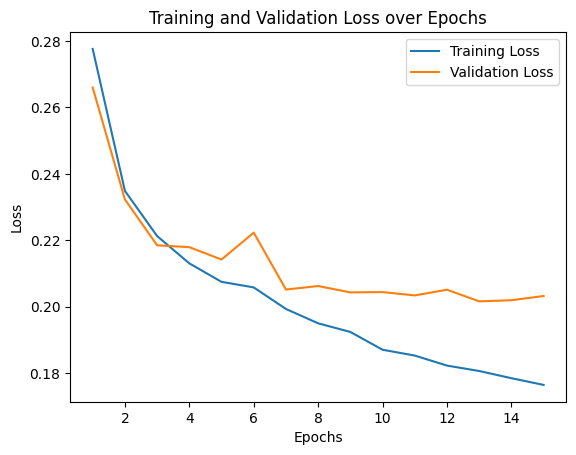

In [16]:
import matplotlib.pyplot as plt
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), valid_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()


In [ ]:
# Test loop to evaluate the model and print sentence pairs along with their predicted and true similarity scores
similarity_model.eval()  # Put the model in evaluation mode

with torch.no_grad():  # Disable gradient calculations
    for batch in test_loader:
        inputs1, inputs2, labels = batch
        # Move tensors to the GPU
        inputs1 = {key: val.to(device) for key, val in inputs1.items()}
        inputs2 = {key: val.to(device) for key, val in inputs2.items()}
        labels = labels.to(device)

        # Forward pass: Get embeddings for sentence pairs
        embeddings1 = similarity_model(input_ids=inputs1['input_ids'], attention_mask=inputs1['attention_mask'])
        embeddings2 = similarity_model(input_ids=inputs2['input_ids'], attention_mask=inputs2['attention_mask'])

        # Calculate predicted cosine similarity
        predicted_similarity = F.cosine_similarity(embeddings1, embeddings2)
       

        # Detokenize inputs to get the original sentences
        sentences1 = tokenizer.batch_decode(inputs1['input_ids'], skip_special_tokens=True)
        sentences2 = tokenizer.batch_decode(inputs2['input_ids'], skip_special_tokens=True)
        
        # Print each sentence pair, its true similarity, and the predicted similarity
        for i in range(len(sentences1)):
            print(f"Sentence 1: {sentences1[i]}")
            print(f"Sentence 2: {sentences2[i]}")
            print(f"True Similarity: {labels[i].item()/5.0}")  # dividing for scaling to 0-5
            print(f"Predicted Similarity: {predicted_similarity[i].item()}")
            print("-" * 50)
            



In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats

true_similarities = []
predicted_similarities = []

similarity_model.eval()  # Put the model in evaluation mode
with torch.no_grad():  # Disable gradient calculations
    for batch in test_loader:
        inputs1, inputs2, labels = batch
        # Move tensors to the GPU
        inputs1 = {key: val.to(device) for key, val in inputs1.items()}
        inputs2 = {key: val.to(device) for key, val in inputs2.items()}
        labels = labels.to(device)

        # Forward pass: Get embeddings for sentence pairs
        embeddings1 = similarity_model(input_ids=inputs1['input_ids'], attention_mask=inputs1['attention_mask'])
        embeddings2 = similarity_model(input_ids=inputs2['input_ids'], attention_mask=inputs2['attention_mask'])

        # Calculate predicted cosine similarity
        predicted_similarity = F.cosine_similarity(embeddings1, embeddings2)

        # Detokenize inputs to get the original sentences
        sentences1 = tokenizer.batch_decode(inputs1['input_ids'], skip_special_tokens=True)
        sentences2 = tokenizer.batch_decode(inputs2['input_ids'], skip_special_tokens=True)

        # Store true and predicted similarity scores
        for i in range(len(sentences1)):
            true_similarity = labels[i].item() / 5.0  # scaling to 0-1
            pred_similarity = predicted_similarity[i].item()

            true_similarities.append(true_similarity)
            predicted_similarities.append(pred_similarity)

            # Print each sentence pair and their similarities (optional)
            print(f"Sentence 1: {sentences1[i]}")
            print(f"Sentence 2: {sentences2[i]}")
            print(f"True Similarity: {true_similarity}")
            print(f"Predicted Similarity: {pred_similarity}")
            print("-" * 50)

# Calculate performance metrics
mse = mean_squared_error(true_similarities, predicted_similarities)
mae = mean_absolute_error(true_similarities, predicted_similarities)
pearson_corr, _ = scipy.stats.pearsonr(true_similarities, predicted_similarities)
spearman_corr, _ = scipy.stats.spearmanr(true_similarities, predicted_similarities)

# Print metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Pearson Correlation: {pearson_corr}")
print(f"Spearman Correlation: {spearman_corr}")


Sentence 1: कलमेगी आँधीका कारण चीनमा उच्च सतर्कता
Sentence 2: चीनले कलमेगी आँधीका लागि पहेंलो चेतावनी जारी गरेको छ
True Similarity: 0.8
Predicted Similarity: 0.8182978630065918
--------------------------------------------------
Sentence 1: रातो र हरियो उपहार झोला भित्र कुकुरको टाउको छ।
Sentence 2: एउटा घरपालुवा जनावरले उपहारको झोलामा भएका सामग्रीहरूको छानबिन गर्छ।
True Similarity: 0.7599999904632568
Predicted Similarity: 0.6207391619682312
--------------------------------------------------
Sentence 1: राज्यले म्याकग्राथको गाउँ नजिकैको लगभग १,७०० वर्ग माइल क्षेत्रमा ब्वाँसाहरूलाई मार्न चाहन्छ।
Sentence 2: राज्यले म्याकग्राथ नजिकैको लगभग १,७०० वर्ग माइल क्षेत्रमा ब्वाँसाहरूलाई मार्न चाहान्छ र एक प्रकारको मुस नर्सरी स्थापना गर्न चाहन्छ।
True Similarity: 0.6400000095367432
Predicted Similarity: 0.8986613750457764
--------------------------------------------------
Sentence 1: सिरियाली राजदूतले राष्ट्रिय एकता सरकार गठन गर्न आह्वान गरेका छन्
Sentence 2: सिरियाली राजदूतले द्वन्द्व अन्त्य गर्न 

In [ ]:
from transformers import XLMRobertaTokenizer
import torch
import torch.nn.functional as F

# Load the tokenizer and model
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
# similarity_model = torch.load('path_to_your_trained_model.pt')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
similarity_model = similarity_model.to(device)

# Define your sentences
text1 = "हालैको फुटबल समाचार अनुसार, नेपाली राष्ट्रिय फुटबल टोलीले दक्षिण एसियाली फुटबल महासंघ (साफ) च्याम्पियनसिपको तयारी गरिरहेको छ। नेपाली टोलीले हालैको अभ्यास खेलहरूमा राम्रो प्रदर्शन गर्दै आएको छ।  "
text2 = "गत वर्ष चर्चित भारतीय संगीतकार शान्तनु मोइत्रा आनी छोइङ डोल्मालाई भेट्न सुटुक्क काठमाडौं आए ।"

# Tokenize the sentences
inputs1 = tokenizer(text1, return_tensors='pt', padding=True, truncation=True, max_length=128)
inputs2 = tokenizer(text2, return_tensors='pt', padding=True, truncation=True, max_length=128)

# Move tensors to the same device as the model
inputs1 = {key: val.to(device) for key, val in inputs1.items()}
inputs2 = {key: val.to(device) for key, val in inputs2.items()}

# Get embeddings for the sentences
similarity_model.eval()  # Put the model in evaluation mode
with torch.no_grad():
    embeddings1 = similarity_model(input_ids=inputs1['input_ids'], attention_mask=inputs1['attention_mask'])
    embeddings2 = similarity_model(input_ids=inputs2['input_ids'], attention_mask=inputs2['attention_mask'])

    # Calculate cosine similarity
    predicted_similarity = F.cosine_similarity(embeddings1, embeddings2)
    

# Print the similarity score
print(f"Sentence 1: {text1}")
print(f"Sentence 2: {text2}")
print(f"Predicted Similarity: {predicted_similarity.item()}")


In [19]:
# Save the trained model and tokenizer
model.save_pretrained('/kaggle/working/similarity_model')
tokenizer.save_pretrained('/kaggle/working/similarity_tokenizer')


('/kaggle/working/similarity_tokenizer/tokenizer_config.json',
 '/kaggle/working/similarity_tokenizer/special_tokens_map.json',
 '/kaggle/working/similarity_tokenizer/sentencepiece.bpe.model',
 '/kaggle/working/similarity_tokenizer/added_tokens.json',
 '/kaggle/working/similarity_tokenizer/tokenizer.json')

In [20]:
model.save_pretrained('/kaggle/working/similarity_model')


In [21]:
import os

# Specify the directory
directory = '/kaggle/working/similarity_model'

# List and print all files in the directory
if os.path.exists(directory):
    files = os.listdir(directory)
    print("Files in 'similarity_model' directory:")
    for file in files:
        print(file)
else:
    print(f"Directory {directory} does not exist.")


Files in 'similarity_model' directory:
model.safetensors
config.json


In [22]:
import os

# Specify the directory
directory = '/kaggle/working/similarity_tokenizer'

# List and print all files in the directory
if os.path.exists(directory):
    files = os.listdir(directory)
    print("Files in 'similarity_tokenizer' directory:")
    for file in files:
        print(file)
else:
    print(f"Directory {directory} does not exist.")

Files in 'similarity_tokenizer' directory:
sentencepiece.bpe.model
special_tokens_map.json
tokenizer.json
tokenizer_config.json


In [24]:
import zipfile
import os

# Define the paths to the directories you want to zip
model_dir = '/kaggle/working/similarity_model'
tokenizer_dir = '/kaggle/working/similarity_tokenizer'

# Define the output zip file name
output_zip = '/kaggle/working/similarity_model_and_tokenizer.zip'

# Create a zip file containing both directories
with zipfile.ZipFile(output_zip, 'w') as zip_file:
    # Zip the model directory
    for foldername, subfolders, filenames in os.walk(model_dir):
        for filename in filenames:
            file_path = os.path.join(foldername, filename)
            arcname = os.path.relpath(file_path, start=model_dir)  # Preserve folder structure
            zip_file.write(file_path, arcname=os.path.join('similarity_model', arcname))

    # Zip the tokenizer directory
    for foldername, subfolders, filenames in os.walk(tokenizer_dir):
        for filename in filenames:
            file_path = os.path.join(foldername, filename)
            arcname = os.path.relpath(file_path, start=tokenizer_dir)  # Preserve folder structure
            zip_file.write(file_path, arcname=os.path.join('similarity_tokenizer', arcname))

print(f"Zipped directories into {output_zip}")


Zipped directories into /kaggle/working/similarity_model_and_tokenizer.zip
